**CUSTOMER CHURN PREDICITON FOR TELECOM INDUSTRY**

Dataset: Sample Data Set containing Telco customer data and showing customers left last month


In [4]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.ticker as mtick  
import matplotlib.pyplot as plt
%matplotlib inline

<!-- loading file -->

Loading dataset:

In [6]:
telco_base_data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
telco_base_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Checking the attributes:

In [ ]:
telco_base_data.shape

(7043, 21)

In [9]:
telco_base_data.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

Checking datatypes:

In [10]:
telco_base_data.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Descriptive Statistics of numeric Variables:

In [11]:
telco_base_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


SeniorCitizen is actually a categorical hence the 25%-50%-75% distribution is not propoer

75% customers have tenure less than 55 months

Average Monthly charges are USD 64.76 whereas 25% customers pay more than USD 89.85 per month

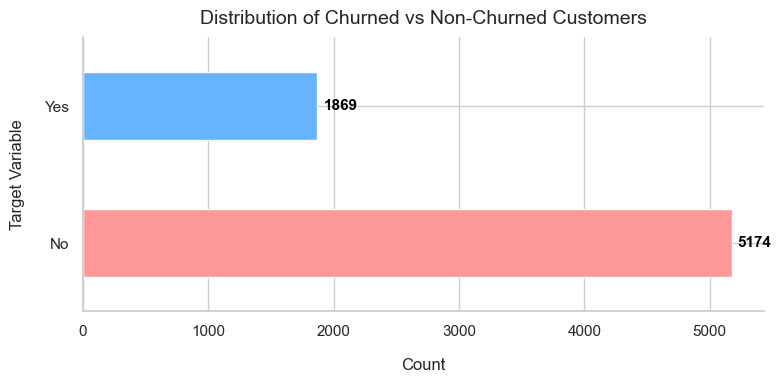

In [243]:

sns.set(style="whitegrid")
plt.figure(figsize=(8, 4))
colors = ['#FF9999', '#66B3FF']
ax = telco_base_data['Churn'].value_counts().plot(
    kind='barh', 
    color=colors, 
    edgecolor='white'
)

plt.xlabel("Count", labelpad=14, fontsize=12)
plt.ylabel("Target Variable", labelpad=14, fontsize=12)
plt.title("Distribution of Churned vs Non-Churned Customers", fontsize=14, y=1.02)

for i, v in enumerate(telco_base_data['Churn'].value_counts()):
    ax.text(v + 50, i, str(v), color='black', fontweight='bold', va='center', fontsize=11)

sns.despine()

plt.tight_layout()
plt.show()


In [21]:

100*telco_base_data['Churn'].value_counts()/len(telco_base_data['Churn'])

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

In [22]:
telco_base_data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

* Data is highly imbalanced, ratio = 73:27
* So we analyse the data with other features while taking the target values separately to get some insights.

Concise summary of dataframe:

In [23]:
telco_base_data.info(verbose = True) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


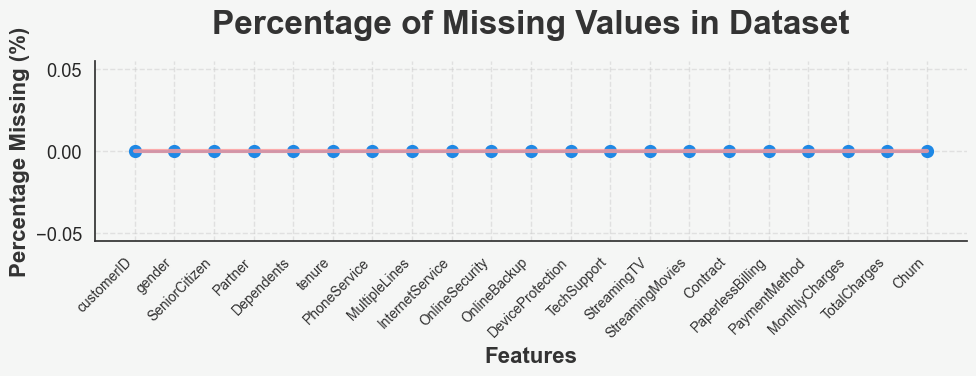

In [245]:

missing = pd.DataFrame((telco_base_data.isnull().sum()) * 100 / telco_base_data.shape[0]).reset_index()
missing.columns = ['Feature', 'Percentage']

plt.figure(figsize=(10, 4), facecolor='#F5F6F5')  

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

ax = sns.pointplot(x='Feature', y='Percentage', data=missing, 
                   color='#1E88E5', markers='o', 
                   dodge=False, errorbar=None, 
                   linewidth=2, markersize=8)  
plt.plot(missing['Feature'], missing['Percentage'], 
         color='#FF9999', linewidth=3, linestyle='-', alpha=0.8)

ax.set_facecolor('#F5F6F5')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlabel("Features", fontsize=16, weight='bold', color='#333333')
ax.set_ylabel("Percentage Missing (%)", fontsize=16, weight='bold', color='#333333')

plt.xticks(rotation=45, ha='right', fontsize=10, color='#333333')

plt.title("Percentage of Missing Values in Dataset", fontsize=24, weight='bold', 
          color='#333333', pad=20)

for i, row in missing.iterrows():
    if row['Percentage'] > 5:
        ax.annotate(f"{row['Percentage']:.1f}%", 
                    (i, row['Percentage']), 
                    xytext=(0, 5), 
                    textcoords="offset points", 
                    ha='center', fontsize=9, color='#D81B60')

plt.tight_layout()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

plt.show()

**Missing Data - Initial Intuition**
* Here, we don't have any missing data.

General Thumb Rules:

* For features with less missing values- can use regression to predict the missing values or fill with the mean of the values present, depending on the feature.
* For features with very high number of missing values- it is better to drop those columns as they give very less insight on analysis.
* As there's no thumb rule on what criteria do we delete the columns with high number of missing values, but generally you can delete the columns, if you have more than 30-40% of missing values. But again there's a catch here, for example, Is_Car & Car_Type, People having no cars, will obviously have Car_Type as NaN (null), but that doesn't make this column useless, so decisions has to be taken wisely.

## **DATA CLEANING**

* Create a copy of base data for manupulation & processing

In [117]:
telco_data = telco_base_data.copy()

* Total Charges should be numeric amount. Let's convert it to numerical data type

In [118]:
telco_data.TotalCharges = pd.to_numeric(telco_data.TotalCharges, errors='coerce')
telco_data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

* As we can see there are 11 missing values in TotalCharges column. Let's check these records

In [119]:
telco_data.loc[telco_data ['TotalCharges'].isnull() == True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


* Missing Value Treatement

Since the % of these records compared to total dataset is very low ie 0.15%, it is safe to ignore them from further processing.

In [120]:
telco_data.dropna(how = 'any', inplace = True)

*  Divide customers into bins based on tenure e.g. for tenure < 12 months: assign a tenure group if 1-12, for tenure between 1 to 2 Yrs, tenure group of 13-24; so on...

In [121]:
print(telco_data['tenure'].max()) 

72


In [122]:
labels = ["{0} - {1}".format(i, i + 11) for i in range(1, 72, 12)]

telco_data['tenure_group'] = pd.cut(telco_data.tenure, range(1, 80, 12), right=False, labels=labels)

In [123]:
telco_data['tenure_group'].value_counts()

tenure_group
1 - 12     2175
61 - 72    1407
13 - 24    1024
25 - 36     832
49 - 60     832
37 - 48     762
Name: count, dtype: int64

* Remove columns not required for processing

In [124]:
telco_data.drop(columns= ['customerID','tenure'], axis=1, inplace=True)
telco_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


### **DATA EXPLORATION**

Plot distibution of individual predictors by churn

**UNIVARIATE ANALYSIS**

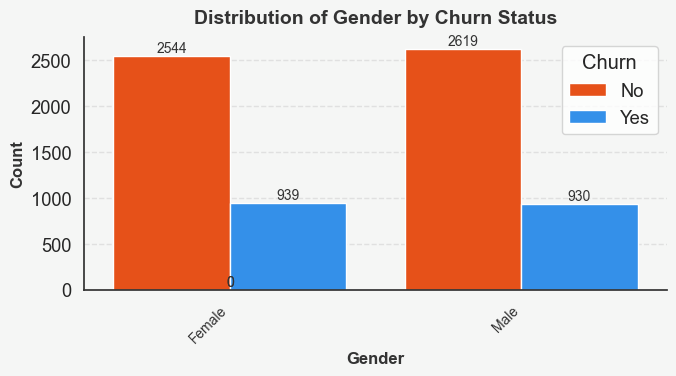

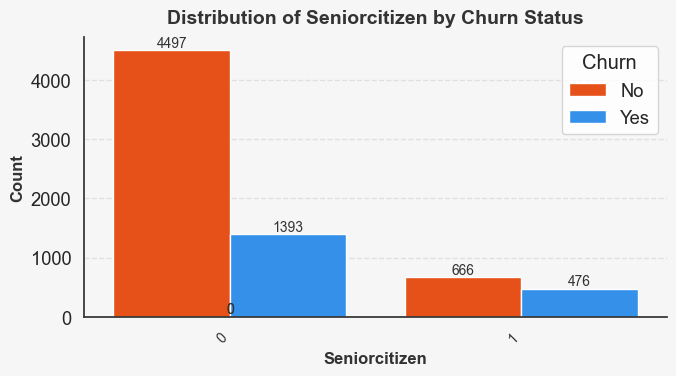

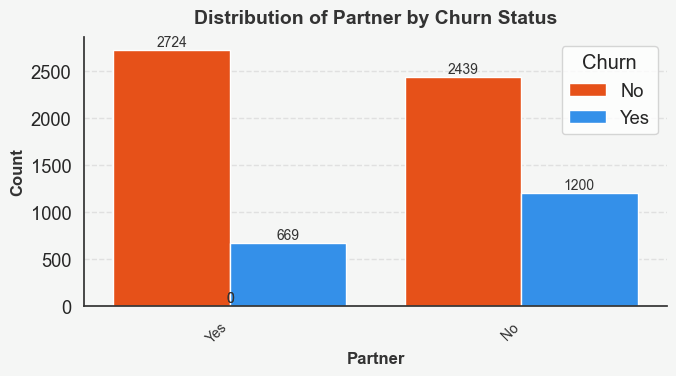

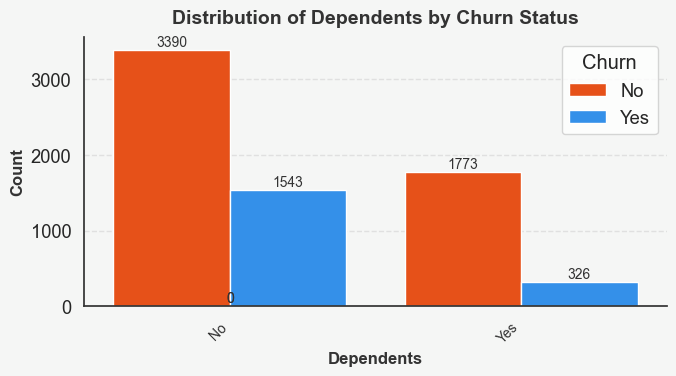

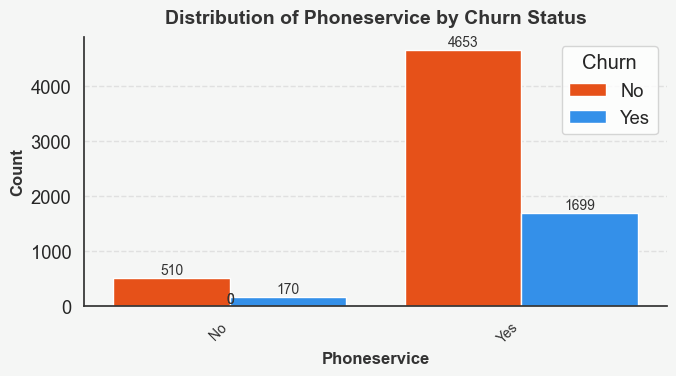

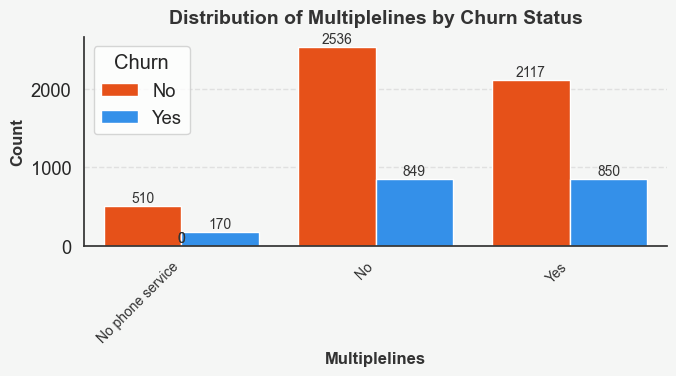

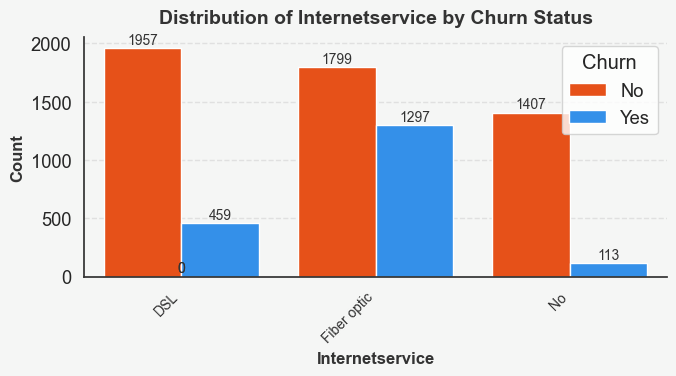

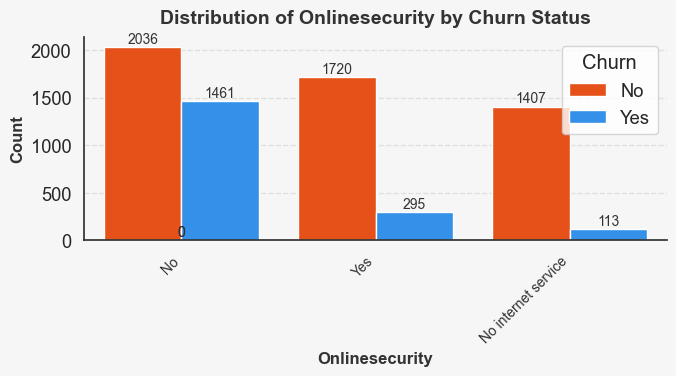

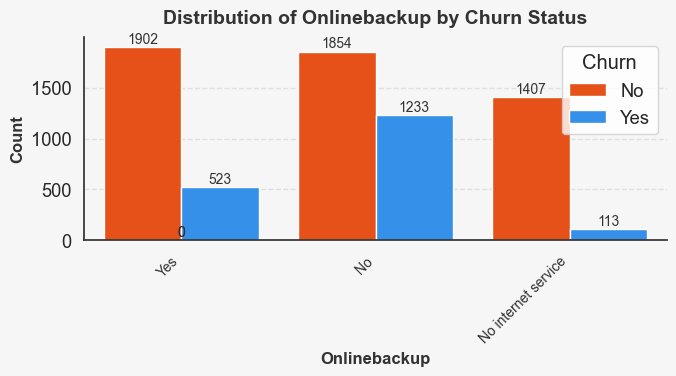

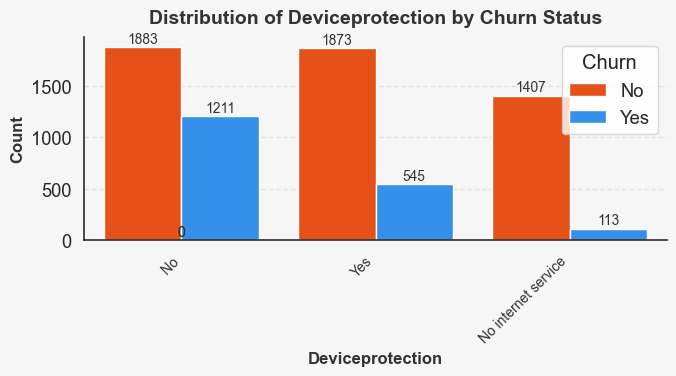

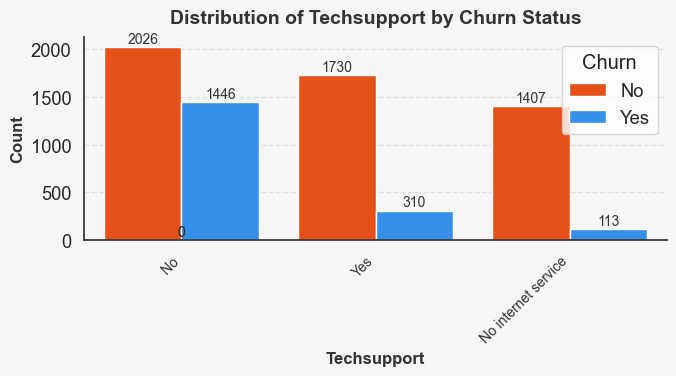

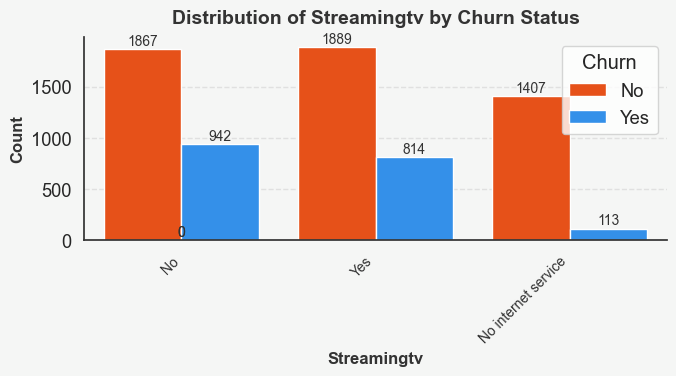

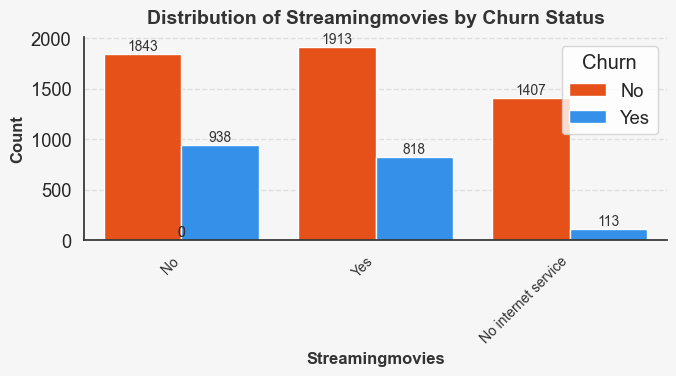

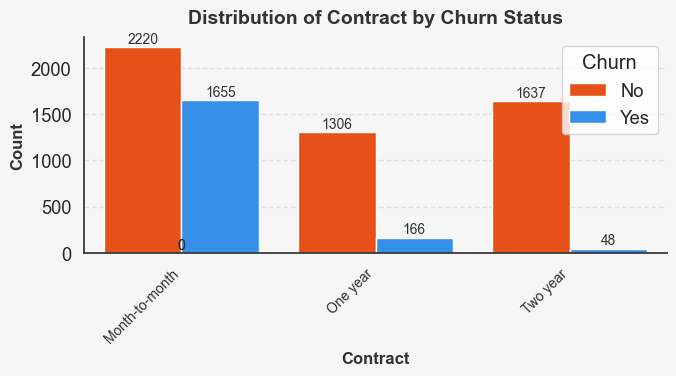

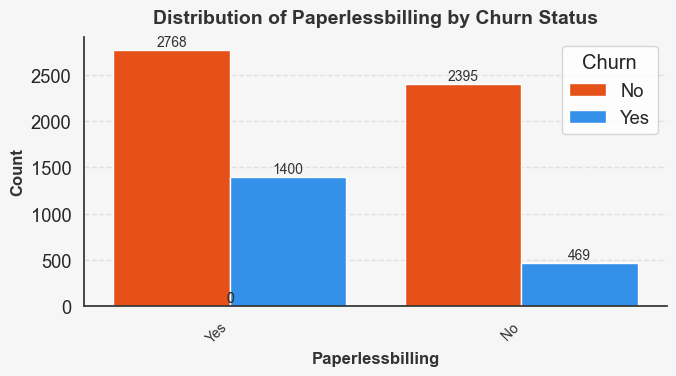

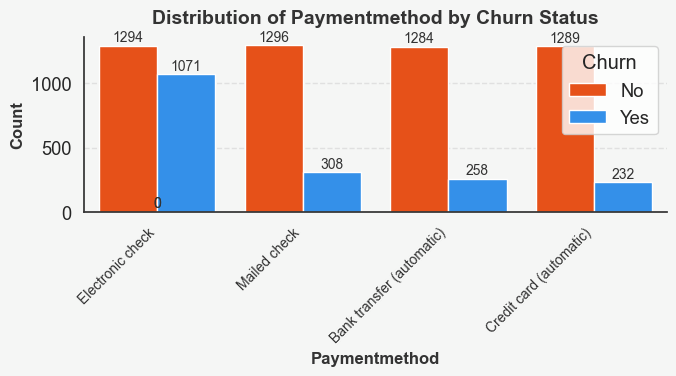

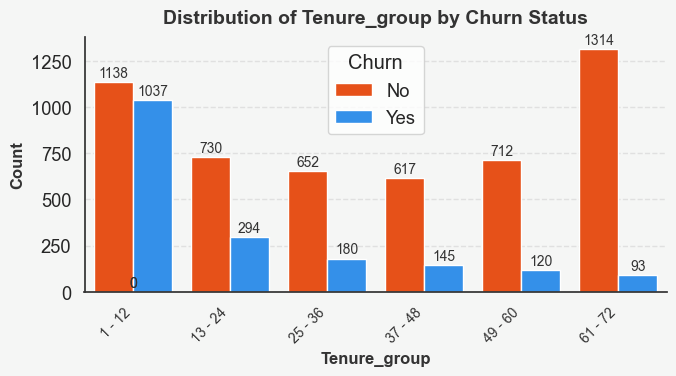

In [246]:


predictors = telco_data.drop(columns=['Churn', 'TotalCharges', 'MonthlyCharges'])

for i, predictor in enumerate(predictors):

    plt.figure(i, figsize=(7, 4), facecolor='#F5F6F5')

    sns.set_style("whitegrid")
    sns.set_context("notebook", font_scale=1.2)

    ax = sns.countplot(data=telco_data, x=predictor, hue='Churn',
                       palette={'Yes': '#1E90FF', 'No': '#FF4500'},  
                       saturation=0.8, dodge=True)  

    ax.set_facecolor('#F5F6F5')
    ax.grid(True, linestyle='--', alpha=0.5, axis='y')  
    ax.set_xlabel(predictor.capitalize(), fontsize=12, weight='bold', color='#333333')
    ax.set_ylabel("Count", fontsize=12, weight='bold', color='#333333')
    
   
    plt.xticks(rotation=45, ha='right', fontsize=10, color='#333333')
  
    plt.title(f"Distribution of {predictor.capitalize()} by Churn Status", 
              fontsize=14, weight='bold', color='#333333', pad=10)

    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2., height + 10,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10, color='#333333')
 
    plt.tight_layout()

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
   
    plt.show()



Convert the target variable 'Churn' in a binary numeric variable i.e. Yes=1 ; No = 0

In [101]:
telco_data['Churn'] = np.where(telco_data.Churn == 'Yes',1,0)
telco_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1 - 12


Convert all the categorical variables into dummy variables

In [102]:
telco_data_dummies = pd.get_dummies(telco_data)
telco_data_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,29.85,29.85,0,True,False,False,True,True,False,...,False,False,True,False,True,False,False,False,False,False
1,0,56.95,1889.50,0,False,True,True,False,True,False,...,False,False,False,True,False,False,True,False,False,False
2,0,53.85,108.15,1,False,True,True,False,True,False,...,False,False,False,True,True,False,False,False,False,False
3,0,42.30,1840.75,0,False,True,True,False,True,False,...,True,False,False,False,False,False,False,True,False,False
4,0,70.70,151.65,1,True,False,True,False,True,False,...,False,False,True,False,True,False,False,False,False,False


Relationship between Monthly Charges and Total Charges

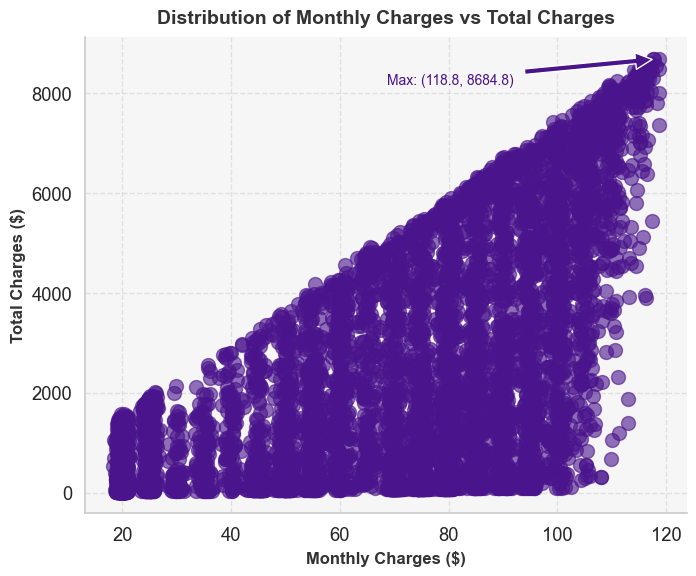

In [168]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.lmplot(data=telco_data_dummies, x='MonthlyCharges', y='TotalCharges', 
                fit_reg=False,  
                scatter_kws={'s': 100, 'alpha': 0.6, 'color': '#4A148C'},  
                height=6, aspect=1.2)  

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

g.ax.set_facecolor('#F5F6F5')  
g.ax.grid(True, linestyle='--', alpha=0.5)  
plt.xlabel('Monthly Charges ($)', fontsize=12, weight='bold', color='#333333')
plt.ylabel('Total Charges ($)', fontsize=12, weight='bold', color='#333333')


plt.title('Distribution of Monthly Charges vs Total Charges', 
          fontsize=14, weight='bold', color='#333333', pad=10)


max_x = telco_data_dummies['MonthlyCharges'].max()
max_y = telco_data_dummies['TotalCharges'].max()
g.ax.annotate(f'Max: ({max_x:.1f}, {max_y:.1f})', 
              xy=(max_x, max_y), xytext=(max_x - 50, max_y - 500),
              arrowprops=dict(facecolor='#4A148C', shrink=0.05),
              fontsize=10, color='#4A148C')

sns.despine()

plt.tight_layout()

plt.show()

Total Charges increase as Monthly Charges increase - as expected.

*  Churn by Monthly Charges and Total Charges

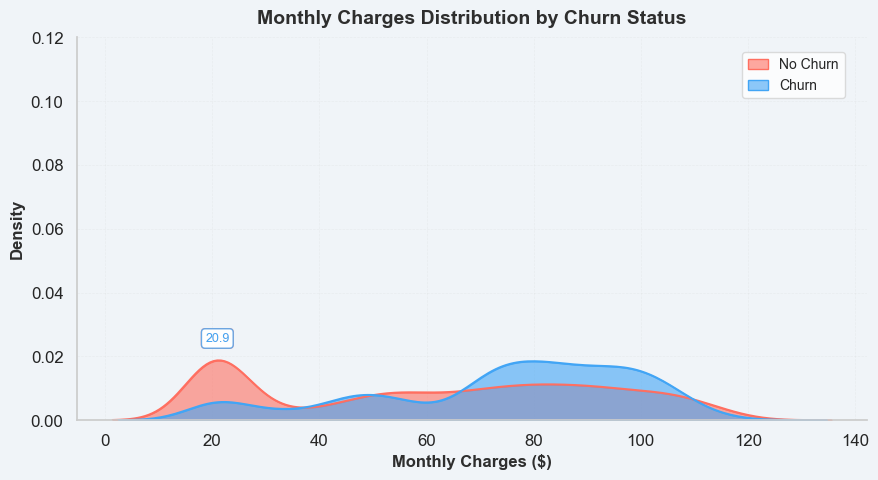

In [190]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5), facecolor='#F0F4F8')

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)


Mth = sns.kdeplot(data=telco_data_dummies.MonthlyCharges[(telco_data_dummies["Churn"] == 0)],
                  color="#FF6F61", fill=True, alpha=0.6)  
Mth = sns.kdeplot(data=telco_data_dummies.MonthlyCharges[(telco_data_dummies["Churn"] == 1)],
                  ax=Mth, color="#42A5F5", fill=True, alpha=0.6)  

Mth.set_facecolor('#F0F4F8')  
Mth.grid(True, linestyle='--', alpha=0.2, linewidth=0.5)  
Mth.set_xlabel('Monthly Charges ($)', fontsize=12, weight='bold', color='#2E2E2E')
Mth.set_ylabel('Density', fontsize=12, weight='bold', color='#2E2E2E')
Mth.set_ylim(0, 0.12) 


Mth.set_title('Monthly Charges Distribution by Churn Status', 
              fontsize=14, weight='bold', color='#2E2E2E', pad=10)
Mth.legend(labels=['No Churn', 'Churn'], loc='upper right', 
           frameon=True, facecolor='#FFFFFF', edgecolor='#D3D3D3', 
           fontsize=10, labelspacing=0.5, handlelength=1.5, 
           bbox_to_anchor=(0.98, 0.98))  


for i, color in enumerate(['#FF6F61', '#42A5F5']):
    kde_data = telco_data_dummies.MonthlyCharges[telco_data_dummies["Churn"] == i]
    kde = sns.kdeplot(kde_data, color=color, fill=False, ax=Mth) 
    x, y = kde.get_lines()[0].get_data()
    peak_idx = y.argmax()

    x_offset = 0 if x[peak_idx] < Mth.get_xlim()[1] - 10 else -5
    Mth.text(x[peak_idx] + x_offset, y[peak_idx] + 0.005, f'{x[peak_idx]:.1f}', 
             ha='center', va='bottom', fontsize=9, color=color, 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor=color, boxstyle='round'))


sns.despine()

plt.tight_layout()

plt.show()

Insight: Churn is high when Monthly Charges are high

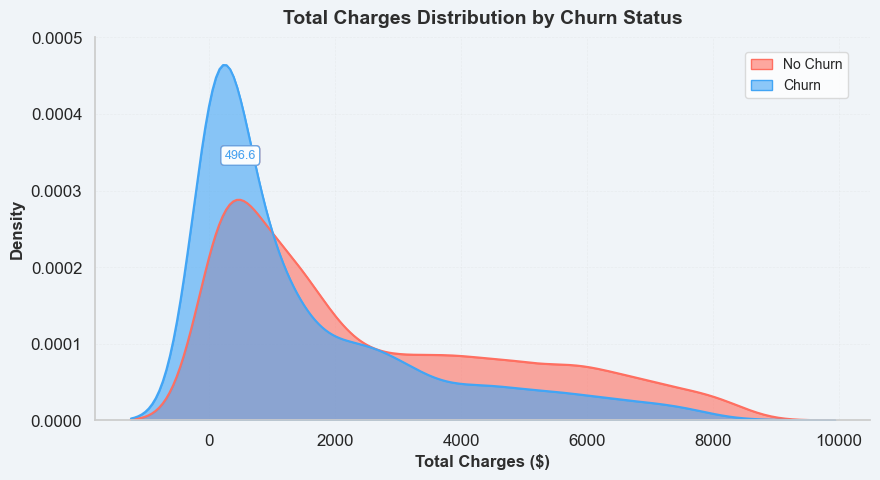

In [193]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5), facecolor='#F0F4F8')

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

Tot = sns.kdeplot(data=telco_data_dummies.TotalCharges[(telco_data_dummies["Churn"] == 0)],
                  color="#FF6F61", fill=True, alpha=0.6)  
Tot = sns.kdeplot(data=telco_data_dummies.TotalCharges[(telco_data_dummies["Churn"] == 1)],
                  ax=Tot, color="#42A5F5", fill=True, alpha=0.6)  
Tot.set_facecolor('#F0F4F8')  
Tot.grid(True, linestyle='--', alpha=0.2, linewidth=0.5) 
Tot.set_xlabel('Total Charges ($)', fontsize=12, weight='bold', color='#2E2E2E')
Tot.set_ylabel('Density', fontsize=12, weight='bold', color='#2E2E2E')
Tot.set_ylim(0, 0.0005) 

Tot.set_title('Total Charges Distribution by Churn Status', 
              fontsize=14, weight='bold', color='#2E2E2E', pad=10)
Tot.legend(labels=['No Churn', 'Churn'], loc='upper right', 
           frameon=True, facecolor='#FFFFFF', edgecolor='#D3D3D3', 
           fontsize=10, labelspacing=0.5, handlelength=1.5, 
           bbox_to_anchor=(0.98, 0.98))  


for i, color in enumerate(['#FF6F61', '#42A5F5']):
    kde_data = telco_data_dummies.TotalCharges[telco_data_dummies["Churn"] == i]
    kde = sns.kdeplot(kde_data, color=color, fill=False, ax=Tot)  
    x, y = kde.get_lines()[0].get_data()
    peak_idx = y.argmax()

    x_offset = 0 if x[peak_idx] < Tot.get_xlim()[1] - 1000 else -500  
    Tot.text(x[peak_idx] + x_offset, y[peak_idx] + 0.00005, f'{x[peak_idx]:.1f}', 
             ha='center', va='bottom', fontsize=9, color=color, 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor=color, boxstyle='round'))

sns.despine()

plt.tight_layout()

plt.show()

**Surprising insight** as higher Churn at lower Total Charges

However if we combine the insights of 3 parameters i.e. Tenure, Monthly Charges & Total Charges then the picture is bit clear :- Higher Monthly Charge at lower tenure results into lower Total Charge. Hence, all these 3 factors viz Higher Monthly Charge, Lower tenure and Lower Total Charge are linkd to High Churn.

*  Build a corelation of all predictors with 'Churn'

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12356\1806348049.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


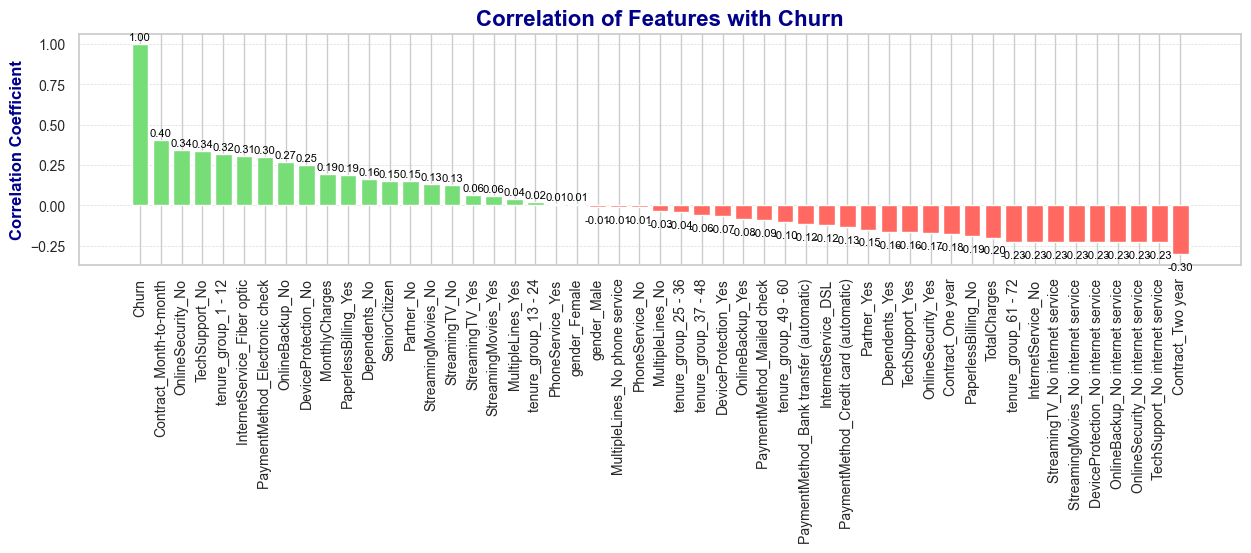

In [248]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = telco_data_dummies.corr()['Churn'].sort_values(ascending=False)

sns.set(style="whitegrid", font_scale=1)

plt.figure(figsize=(15, 3
                    ))
bar_colors = ['#FF6961' if val < 0 else '#77DD77' for val in corr] 

bars = plt.bar(corr.index, corr.values, color=bar_colors)

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01 if height >= 0 else height - 0.05,
             f'{height:.2f}', ha='center', va='bottom' if height >= 0 else 'top', fontsize=8, color='black')

plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.title("Correlation of Features with Churn", fontsize=16, weight='bold', color='darkblue')
plt.ylabel("Correlation Coefficient", fontsize=12, weight='bold', color='darkblue')
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()


**Derived Insight:**

HIGH Churn seen in case of Month to month contracts, No online security, No Tech support, First year of subscription and Fibre Optics Internet

LOW Churn is seens in case of Long term contracts, Subscriptions without internet service and The customers engaged for 5+ years

Factors like Gender, Availability of PhoneService and # of multiple lines have alomost NO impact on Churn

This is also evident from the Heatmap below

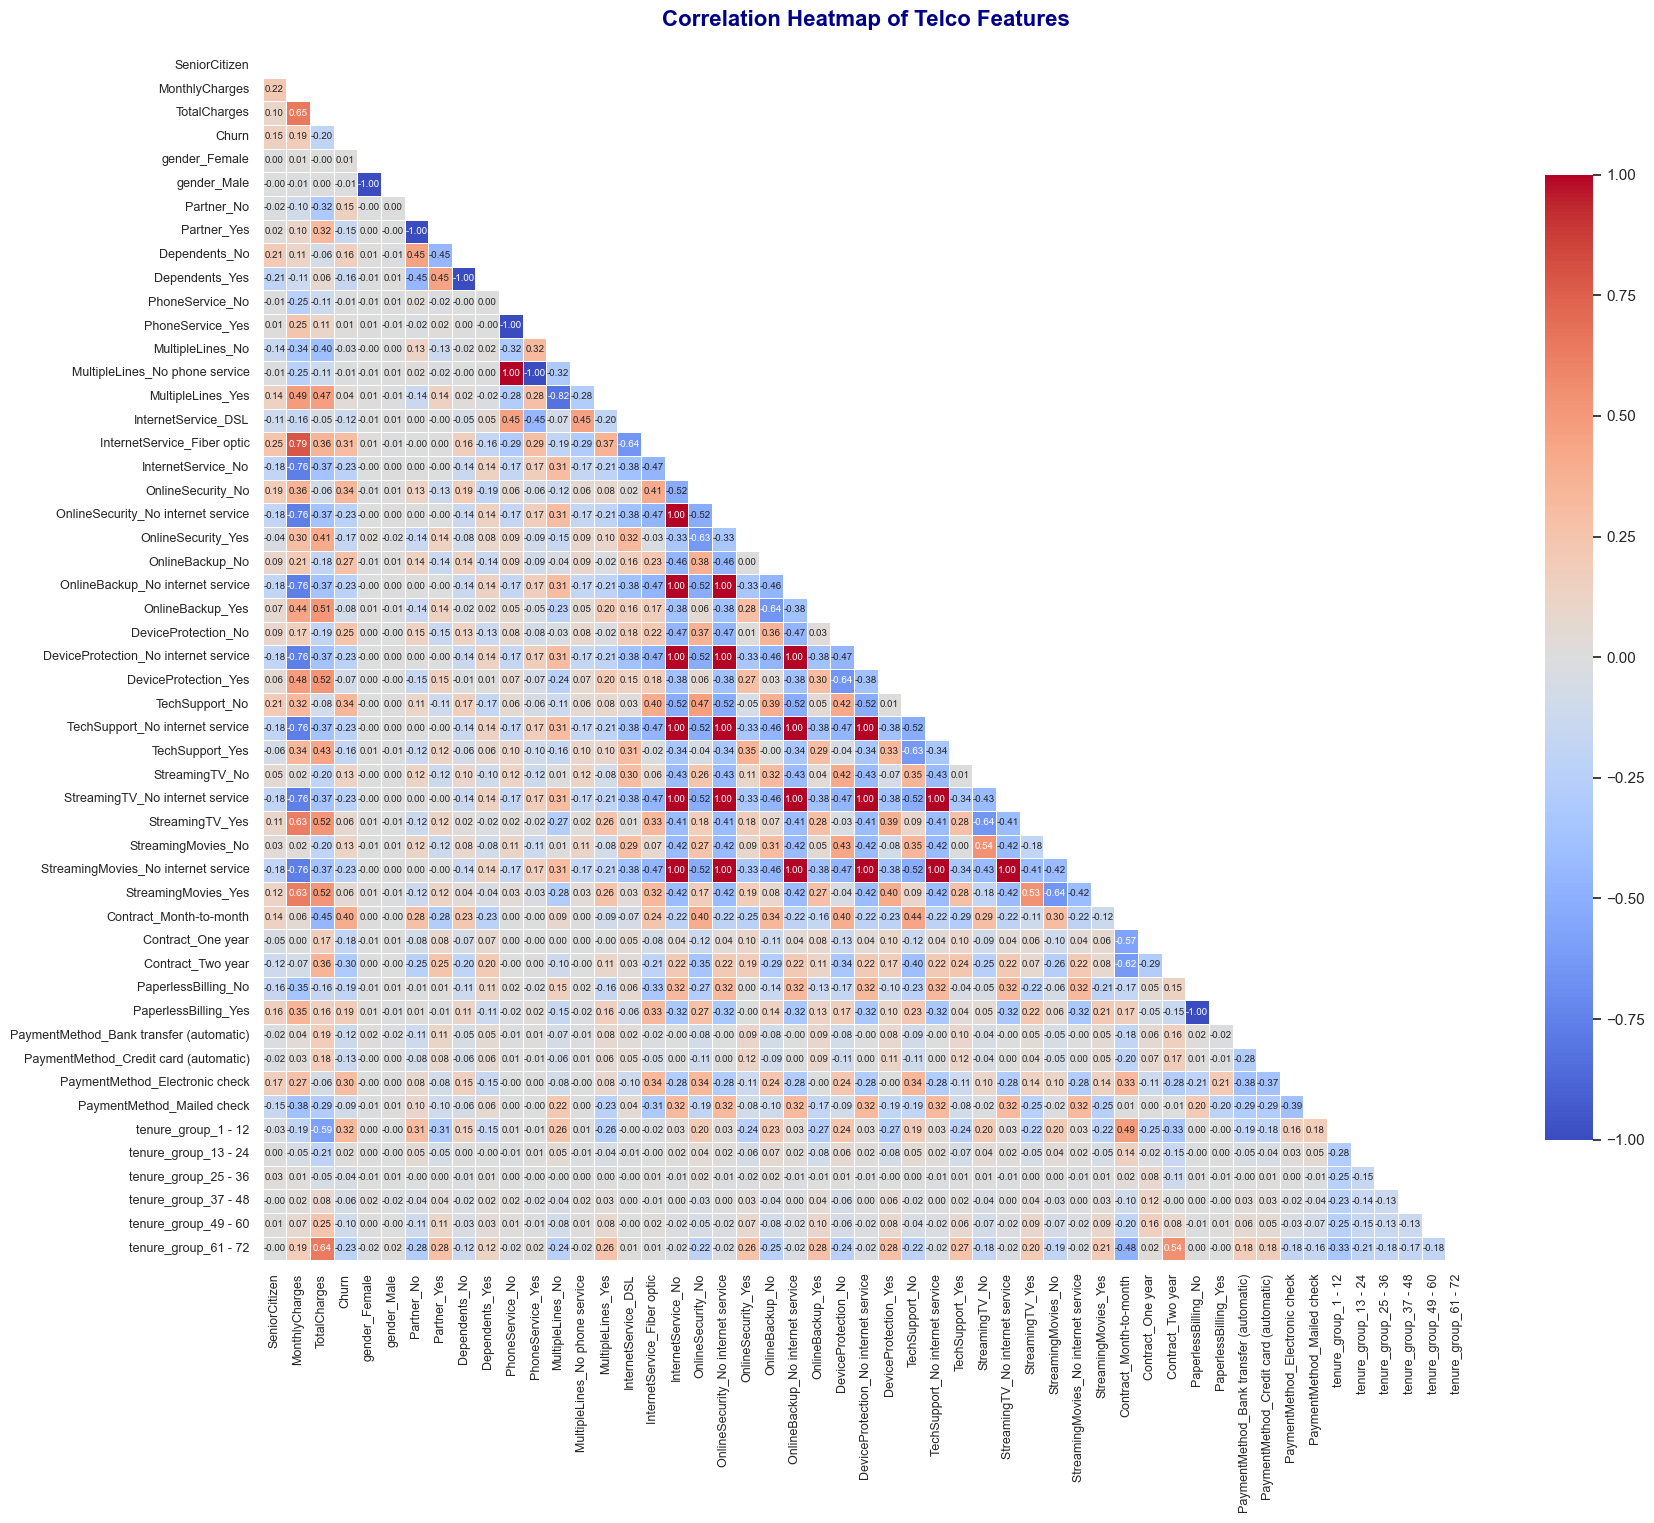

In [250]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


corr = telco_data_dummies.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(18, 15))
sns.set(style="white")

sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',  
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    square=True,
    annot_kws={"size": 7}
)

plt.title("Correlation Heatmap of Telco Features", fontsize=16, weight='bold', color='darkblue', pad=20)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

plt.show()


## **Bivariate Analysis**

In [218]:
new_df1_target0 = telco_data[telco_data["Churn"] == "No"]
new_df1_target1 = telco_data[telco_data["Churn"] == "Yes"]


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12356\2548885468.py:10: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  ax = sns.countplot(data=df, x=col, hue=hue, palette=palette, edgecolor='white', linewidth=1)


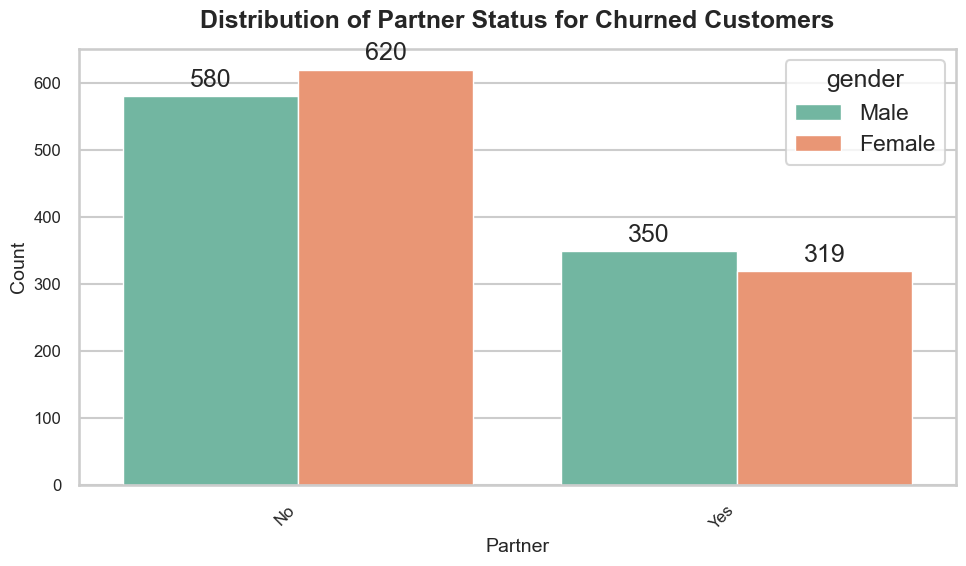

In [252]:
i

def uniplot(df, col, title, hue=None):
    sns.set_style('whitegrid')
    sns.set_context('talk')
    plt.figure(figsize=(10, 6))

    palette = sns.color_palette("Set2")

    ax = sns.countplot(data=df, x=col, hue=hue, palette=palette, edgecolor='white', linewidth=1)

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

    ax.set_title(title, fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel(col, fontsize=14)
    ax.set_ylabel("Count", fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()

uniplot(new_df1_target1, "Partner", "Distribution of Partner Status for Churned Customers", hue="gender")


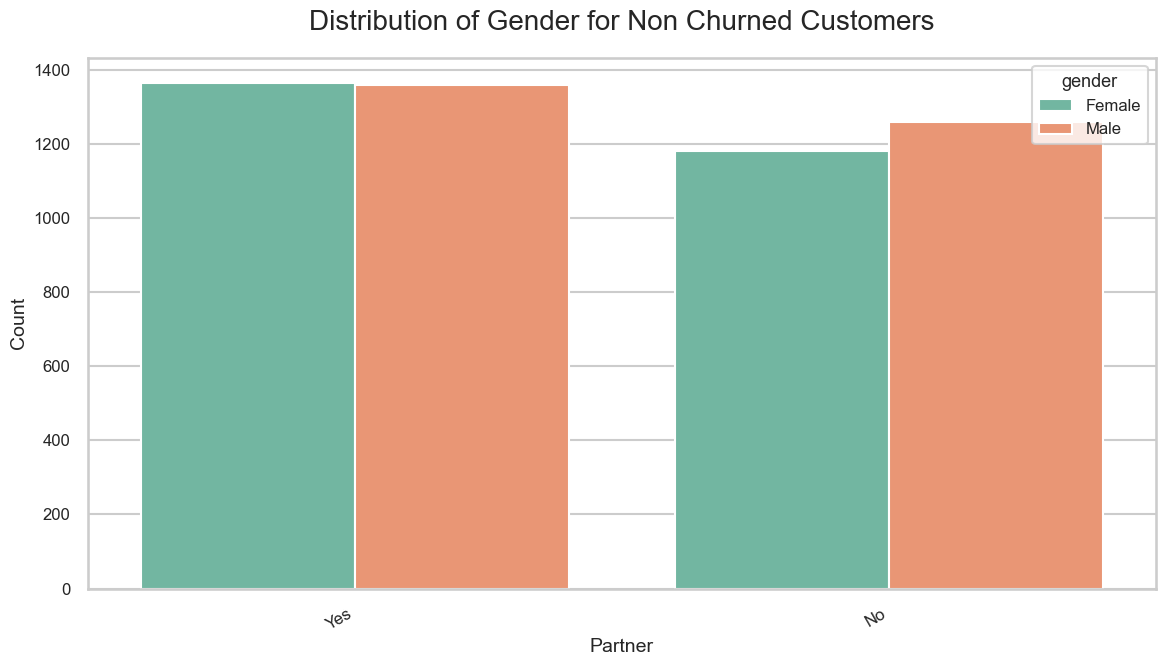

In [234]:

uniplot(new_df1_target0,col='Partner',title='Distribution of Gender for Non Churned Customers',hue='gender')



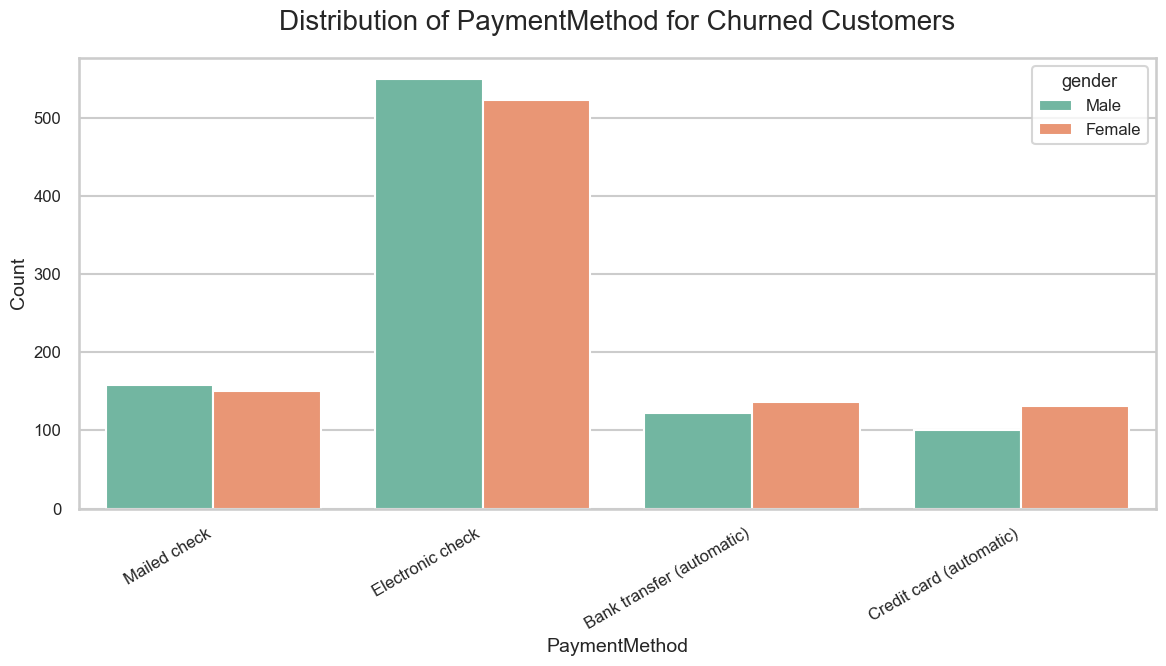

In [235]:
uniplot(new_df1_target1,col='PaymentMethod',title='Distribution of PaymentMethod for Churned Customers',hue='gender')

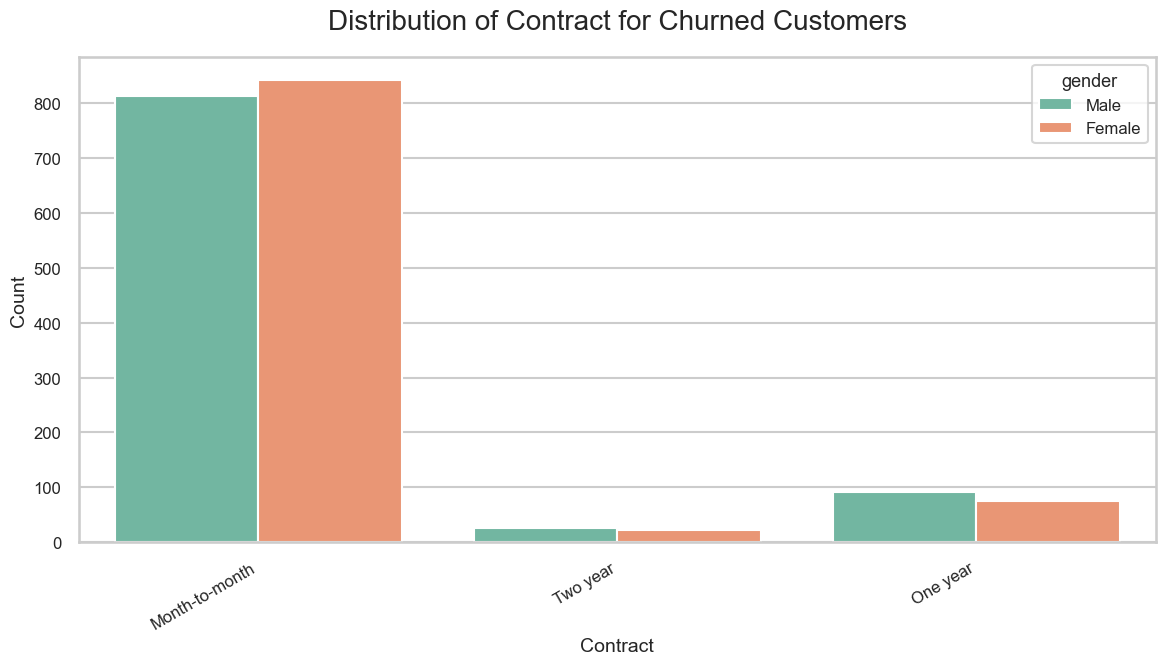

In [236]:
uniplot(new_df1_target1,col='Contract',title='Distribution of Contract for Churned Customers',hue='gender')

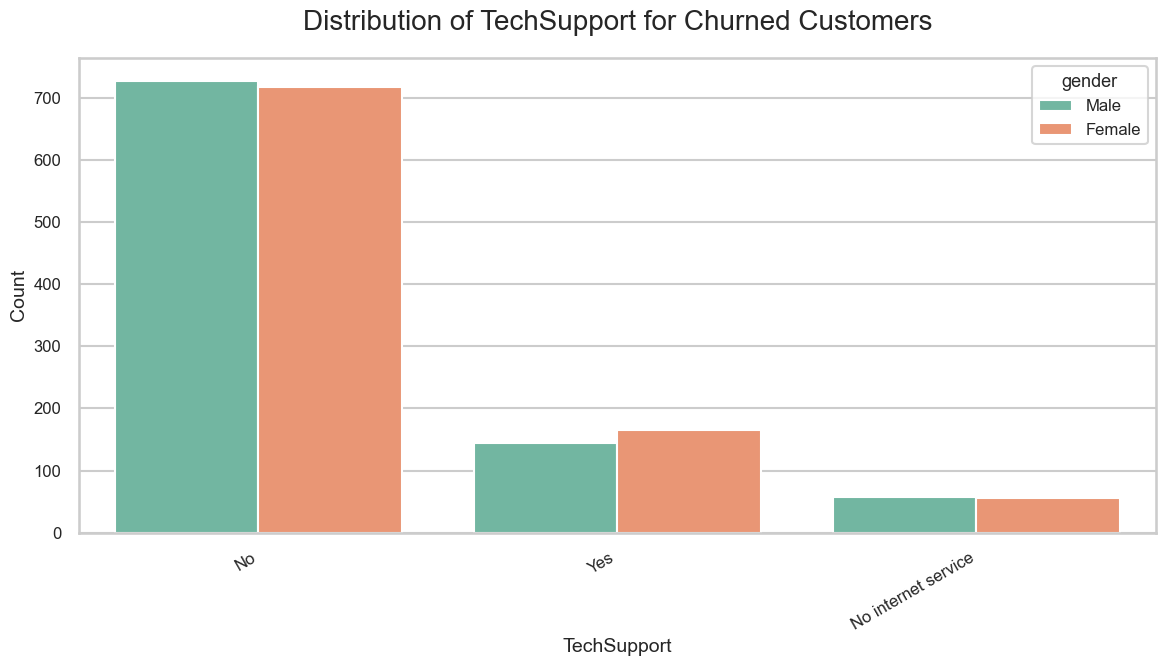

In [237]:
uniplot(new_df1_target1,col='TechSupport',title='Distribution of TechSupport for Churned Customers',hue='gender')

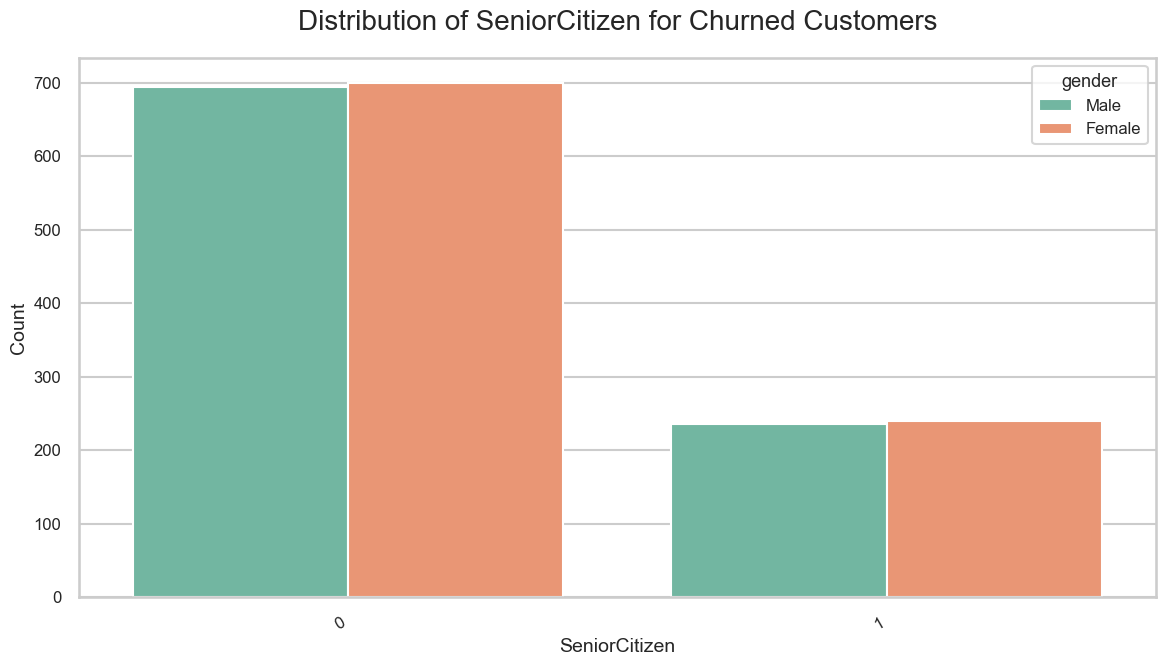

In [238]:
uniplot(new_df1_target1,col='SeniorCitizen',title='Distribution of SeniorCitizen for Churned Customers',hue='gender')

**CONCLUSION**

These are some of the quick insights from this exercise:

1. Electronic check medium are the highest churners
2. Contract Type - Monthly customers are more likely to churn because of no contract terms, as they are free to go customers.
3. No Online security, No Tech Support category are high churners
4. Non senior Citizens are high churners

Note: There could be many more such insights, so take this as an assignment and try to get more insights :)

In [180]:
telco_data_dummies.to_csv('tel_churn.csv')